# South Barnegat Bay Onshore Wind Model Prediction with the Use of Long Short-Term Memory Neural Networks - Graphing

In [687]:
import pandas as pd
import matplotlib.pyplot as plt

In [688]:
import matplotlib as mpl
#mpl.rcParams["font.family"] = "sans-serif"
#mpl.rcParams["font.sans-serif"] = ["Times New Roman"]  # or another installed font
#mpl.rcParams["font.size"] = 12
mpl.rcdefaults()

In [689]:
myfont = {'fontname':'Georgia'}

In [690]:
#Open data as csv
data = pd.read_csv("csv/CLEAN.csv")

#Convert to datetime
#Convert data into Date time and create date filter
data['Date'] = pd.to_datetime(data['Date'])
data['Date'] = data['Date'] + pd.to_timedelta(data["Hr"], unit="h")
data.drop('Hr', axis=1, inplace=True)

In [691]:
raw = pd.read_csv("csv/RAW_data.csv")

#Convert to datetime
#Convert data into Date time and create date filter
raw['Date'] = pd.to_datetime(raw['Date'])
raw['Date'] = raw['Date'] + pd.to_timedelta(raw["Hr"], unit="h")
raw.drop('Hr', axis=1, inplace=True)

In [692]:
#Open data as csv
data_p = pd.read_csv("csv/all_predictions.csv")

In [693]:
data.head()

,Date,Mainland Air Temp,Humidity (%),Direction (A),Wind Speed (A),Gusting,Atmospheric Pressure (IN),Precipitation Rate,Bay Temp,Salinity,LBI Air Temp,Ocean Temp,Onshore,upwelling_flag
0,2025-06-02 00:00:00,13.9,68.0,10,3.8,6.0,29.86,0.00,17.47,27.70,17.8,14.3,0,0
1,2025-06-02 01:00:00,13.6,74.0,12,4.0,6.2,29.88,0.00,17.49,28.20,17.5,14.2,0,0
2,2025-06-02 02:00:00,12.7,78.0,11,3.0,5.4,29.88,0.01,17.27,27.93,16.2,14.2,0,0
3,2025-06-02 03:00:00,11.3,84.0,12,2.7,6.1,29.88,0.00,17.26,28.41,14.9,14.2,0,0
4,2025-06-02 04:00:00,10.3,87.0,13,2.0,3.8,29.89,0.00,16.82,28.42,13.7,14.2,0,0


In [694]:
data_p.head()

,Date,Mainland Air Temp,Humidity (%),Direction (A),Wind Speed (A),Gusting,Atmospheric Pressure (IN),Precipitation Rate,Bay Temp,Salinity,LBI Air Temp,Ocean Temp,Onshore,upwelling_flag,upwelling_pred_naive,onshore_pred_direction,wind_direction_pred_naive,wind_speed_pred_linear,wind_gust_pred_linear,Wind_pred_warning
0,2025-06-02 00:00:00,13.9,68.0,10,3.8,6.0,29.86,0.00,17.47,27.70,17.8,14.3,0,0,NaN,NaN,NaN,NaN,NaN,False
1,2025-06-02 01:00:00,13.6,74.0,12,4.0,6.2,29.88,0.00,17.49,28.20,17.5,14.2,0,0,NaN,NaN,NaN,NaN,NaN,False
2,2025-06-02 02:00:00,12.7,78.0,11,3.0,5.4,29.88,0.01,17.27,27.93,16.2,14.2,0,0,NaN,NaN,NaN,NaN,NaN,False
3,2025-06-02 03:00:00,11.3,84.0,12,2.7,6.1,29.88,0.00,17.26,28.41,14.9,14.2,0,0,NaN,NaN,NaN,NaN,NaN,False
4,2025-06-02 04:00:00,10.3,87.0,13,2.0,3.8,29.89,0.00,16.82,28.42,13.7,14.2,0,0,NaN,NaN,NaN,NaN,NaN,False


### Plot of all variables (Actual)

Text(0, 0.5, 'Air Temperature (C)')

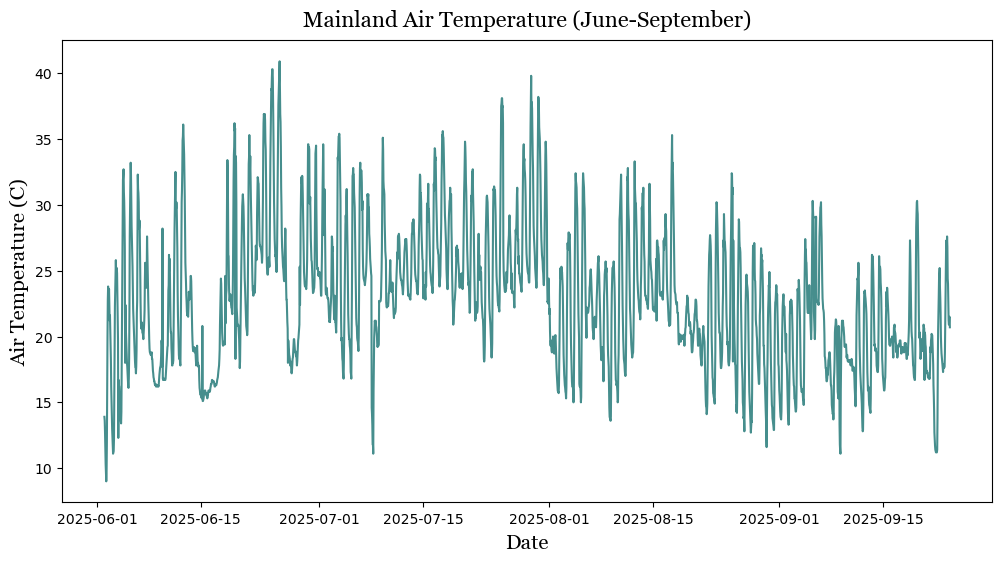

In [695]:
#Plot 1 - Mainland Air Temp

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Mainland Air Temp'], label='Mainland Air Temperature', color='#468e8d')
plt.title("Mainland Air Temperature (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Air Temperature (C)', **myfont, fontsize=15)

Text(0, 0.5, 'Himidity (%)')

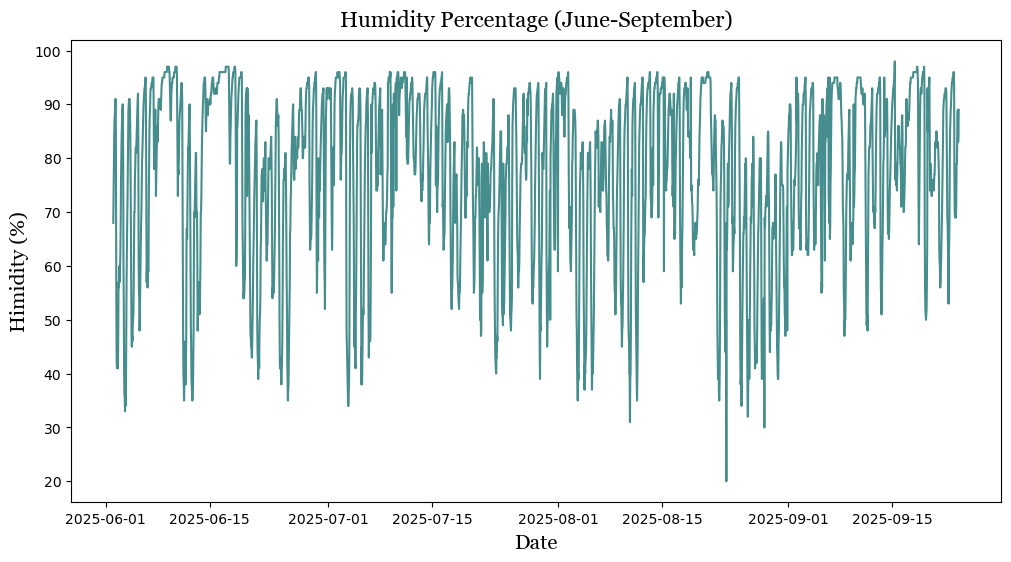

In [696]:
#Plot 2 - Humidity (%)

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Humidity (%)'], label='Humidity (%)', color='#468e8d')
plt.title("Humidity Percentage (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Himidity (%)', **myfont, fontsize=15)

Text(0, 0.5, 'Direction')

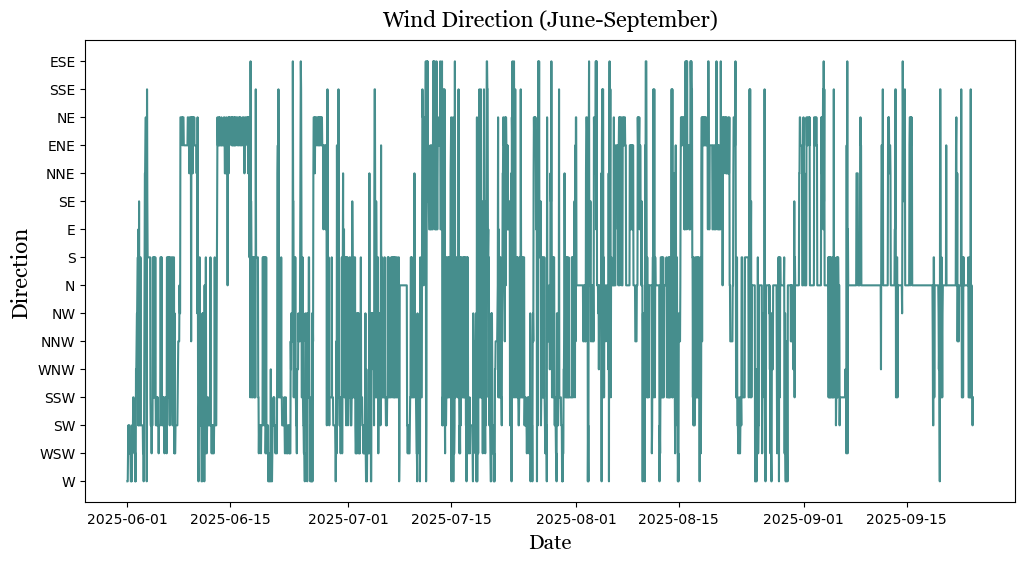

In [697]:
#Plot 3 - Direction over Time? (Not really sure what to do with this one)

plt.figure(figsize=(12,6))
plt.plot(raw['Date'], raw['Direction (A)'], label='Direction', color='#468e8d')
plt.title("Wind Direction (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Direction', **myfont, fontsize=16)

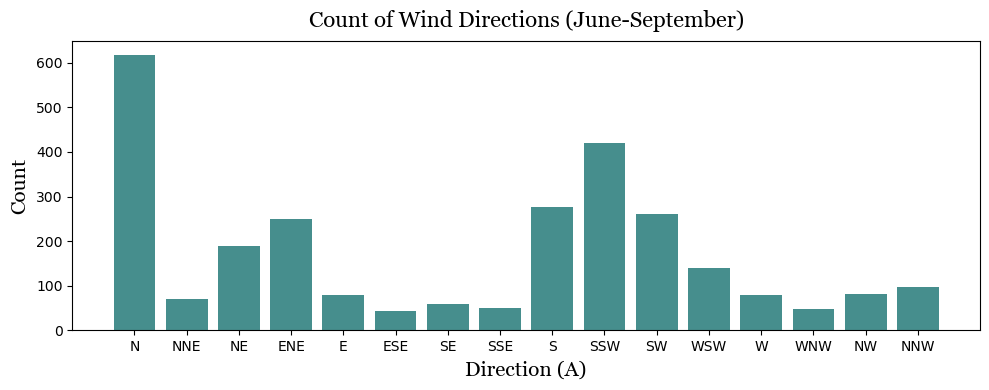

In [698]:
#Plot 4 - Direction Counts

counts = raw["Direction (A)"].value_counts()

order = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
         "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]

labels = order
values = [counts.get(d, 0) for d in order]

plt.figure(figsize=(10, 4))
plt.bar(labels, values, label='Directions', color='#468e8d')
plt.title("Count of Wind Directions (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel("Direction (A)", labelpad=5, **myfont, fontsize=15)
plt.ylabel("Count", labelpad=5, **myfont, fontsize=15)
plt.tight_layout()

Text(0, 0.5, 'Wind Speed (mph)')

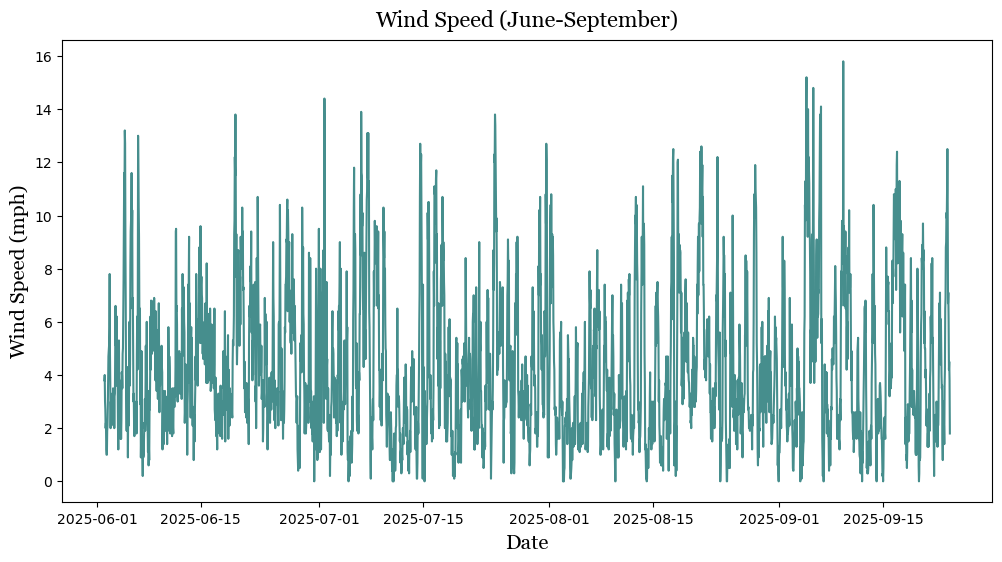

In [699]:
#Plot 5 - Wind Speed 

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Wind Speed (A)'], label='Wind Speed', color='#468e8d')
plt.title("Wind Speed (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Wind Speed (mph)', **myfont, fontsize=15)

Text(0, 0.5, 'Wind Gusting Speed (mph)')

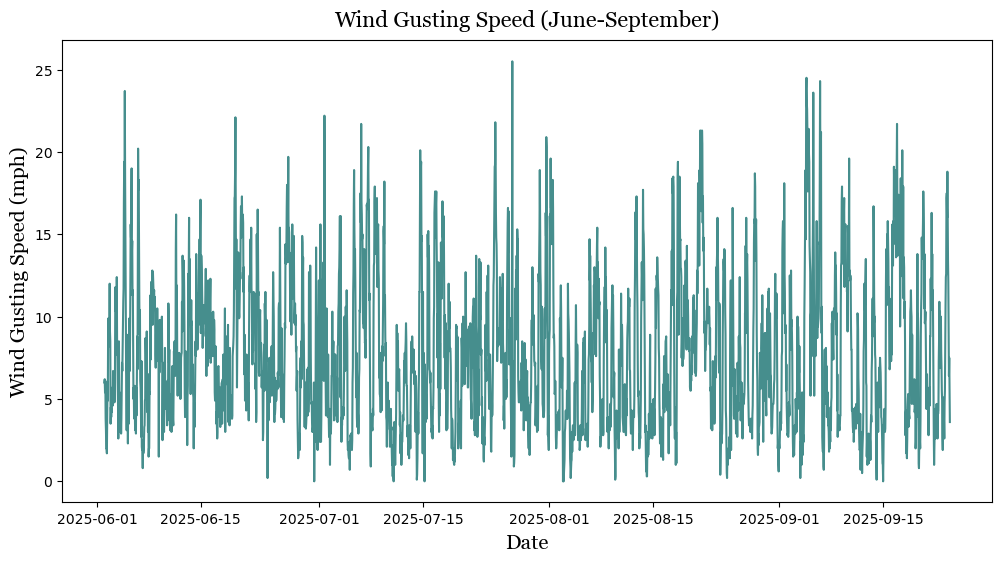

In [700]:
#Plot 6 - Wind Gust Speed 

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Gusting'], label='Wind Gust Speed', color='#468e8d')
plt.title("Wind Gusting Speed (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Wind Gusting Speed (mph)', **myfont, fontsize=15)

Text(0, 0.5, 'Atmospheric Pressure (IN)')

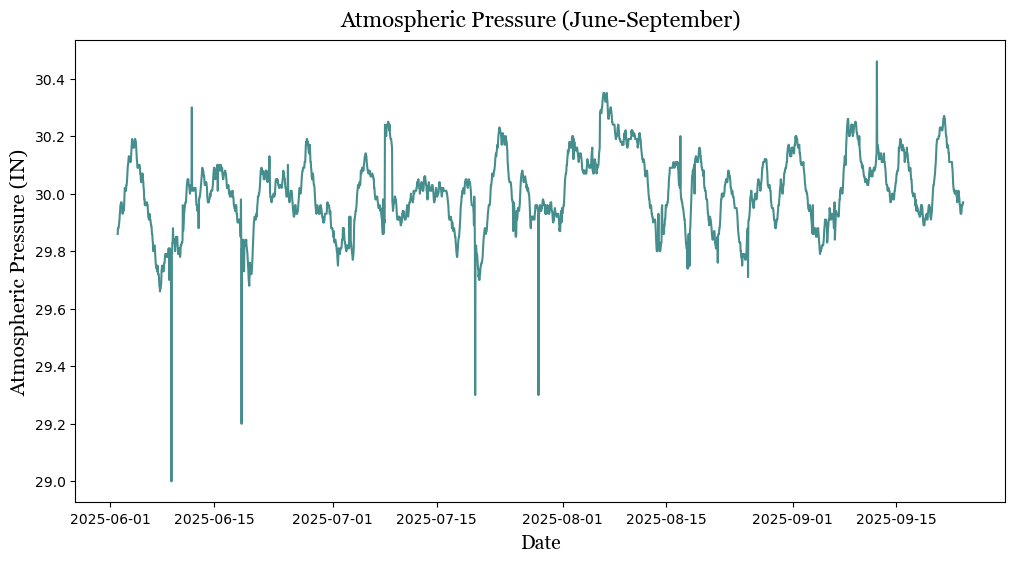

In [701]:
#Plot 7 - Wind Gust Speed 

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Atmospheric Pressure (IN)'], label='Atmospheric Pressure', color='#468e8d')
plt.title("Atmospheric Pressure (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('Atmospheric Pressure (IN)', **myfont, fontsize=15)

Text(0, 0.5, 'Precipitation Rate (IN)')

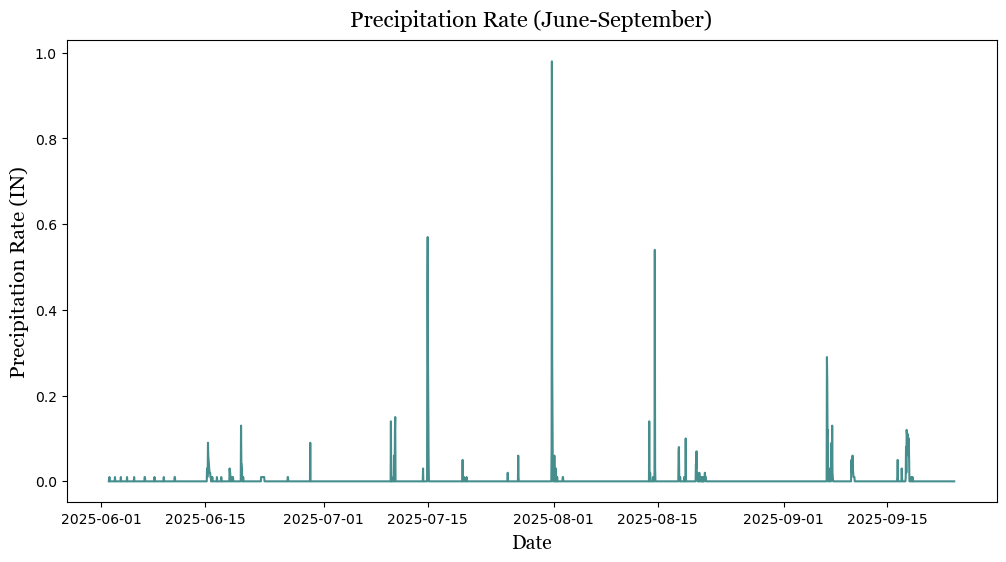

In [702]:
#Plot 8 - Precipitation

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Precipitation Rate'], label='Precipitation Rate', color='#468e8d')
plt.title("Precipitation Rate (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('Precipitation Rate (IN)', **myfont, fontsize=15)

Text(0, 0.5, 'Bay Temperature (C)')

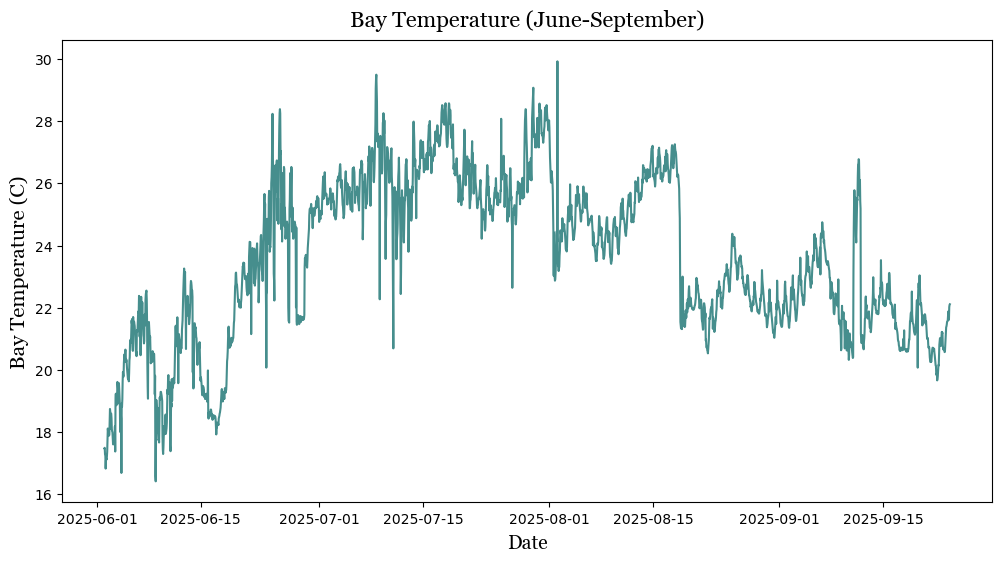

In [703]:
#Plot 8 - Precipitation

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Bay Temp'], label='Bay Temperature', color='#468e8d')
plt.title("Bay Temperature (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('Bay Temperature (C)', **myfont, fontsize=15)

In [ ]:
#Plot 8 - Precipitation

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Salinity'], label='Salinity', color='#468e8d')
plt.title("Bay Salinity (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('Bay Salinity', **myfont, fontsize=15)